In [16]:
import pandas as pd
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)

print('✅ Libraries loaded!')



✅ Libraries loaded!


In [17]:
all_quotes = [
    {"quote": "The only way to do great work is to love what you do.", "author": "Steve Jobs", "tags": "passion, work, growth", "word_count": 14},
    {"quote": "It does not matter how slowly you go as long as you do not stop.", "author": "Confucius", "tags": "perseverance, growth, motivation", "word_count": 16},
    {"quote": "Success is not final, failure is not fatal: it is the courage to continue that counts.", "author": "Winston Churchill", "tags": "resilience, courage, success", "word_count": 16},
    {"quote": "The mind is not a vessel to be filled but a fire to be kindled.", "author": "Plutarch", "tags": "learning, growth, mindset", "word_count": 15},
    {"quote": "Strength does not come from physical capacity. It comes from an indomitable will.", "author": "Mahatma Gandhi", "tags": "strength, empowerment, mindset", "word_count": 13},
    {"quote": "You don't have to be great to start, but you have to start to be great.", "author": "Zig Ziglar", "tags": "action, growth, motivation", "word_count": 16},
    {"quote": "The expert in anything was once a beginner.", "author": "Helen Hayes", "tags": "learning, growth, empowerment", "word_count": 8},
    {"quote": "Push yourself because no one else is going to do it for you.", "author": "Unknown", "tags": "discipline, empowerment, motivation", "word_count": 13},
    {"quote": "Great things never came from comfort zones.", "author": "Unknown", "tags": "growth, challenge, empowerment", "word_count": 7},
    {"quote": "It always seems impossible until it's done.", "author": "Nelson Mandela", "tags": "resilience, empowerment, success", "word_count": 7},
    {"quote": "The only person you are destined to become is the person you decide to be.", "author": "Ralph Waldo Emerson", "tags": "empowerment, growth, mindset", "word_count": 15},
    {"quote": "Don't watch the clock; do what it does. Keep going.", "author": "Sam Levenson", "tags": "perseverance, discipline, motivation", "word_count": 10},
    {"quote": "Learning is not attained by chance. It must be sought with ardour and attended with diligence.", "author": "Abigail Adams", "tags": "learning, discipline, growth", "word_count": 16},
    {"quote": "The secret of getting ahead is getting started.", "author": "Mark Twain", "tags": "action, motivation, growth", "word_count": 8},
    {"quote": "Believe you can and you're halfway there.", "author": "Theodore Roosevelt", "tags": "mindset, empowerment, motivation", "word_count": 7},
    {"quote": "I am not a product of my circumstances. I am a product of my decisions.", "author": "Stephen Covey", "tags": "empowerment, mindset, growth", "word_count": 14},
    {"quote": "The beautiful thing about learning is that no one can take it away from you.", "author": "B.B. King", "tags": "learning, empowerment, growth", "word_count": 15},
    {"quote": "Do something today that your future self will thank you for.", "author": "Sean Patrick Flanery", "tags": "growth, discipline, motivation", "word_count": 11},
    {"quote": "We do not learn from experience. We learn from reflecting on experience.", "author": "John Dewey", "tags": "learning, growth, mindset", "word_count": 12},
    {"quote": "An investment in knowledge pays the best interest.", "author": "Benjamin Franklin", "tags": "learning, growth, knowledge", "word_count": 8},
    {"quote": "Education is the most powerful weapon which you can use to change the world.", "author": "Nelson Mandela", "tags": "learning, empowerment, change", "word_count": 14},
    {"quote": "The capacity to learn is a gift; the ability to learn is a skill; the willingness to learn is a choice.", "author": "Brian Herbert", "tags": "learning, growth, mindset", "word_count": 19},
    {"quote": "Anyone who stops learning is old, whether at twenty or eighty.", "author": "Henry Ford", "tags": "learning, growth, mindset", "word_count": 11},
    {"quote": "You are never too old to set another goal or to dream a new dream.", "author": "C.S. Lewis", "tags": "empowerment, growth, motivation", "word_count": 15},
    {"quote": "If you are not willing to learn, no one can help you. If you are determined to learn, no one can stop you.", "author": "Zig Ziglar", "tags": "learning, empowerment, growth", "word_count": 22},
    {"quote": "Empowerment is not about giving people power, it's about unlocking the power they already have.", "author": "Unknown", "tags": "empowerment, growth, coaching", "word_count": 15},
    {"quote": "Tell me and I forget. Teach me and I remember. Involve me and I learn.", "author": "Benjamin Franklin", "tags": "learning, coaching, growth", "word_count": 14},
    {"quote": "What we learn with pleasure we never forget.", "author": "Alfred Mercier", "tags": "learning, growth, mindset", "word_count": 8},
    {"quote": "Growth is never by mere chance; it is the result of forces working together.", "author": "James Cash Penney", "tags": "growth, discipline, success", "word_count": 14},
    {"quote": "You cannot teach a man anything. You can only help him discover it within himself.", "author": "Galileo Galilei", "tags": "learning, coaching, empowerment", "word_count": 15},
    {"quote": "The only limit to our realisation of tomorrow is our doubts of today.", "author": "Franklin D. Roosevelt", "tags": "mindset, empowerment, growth", "word_count": 13},
    {"quote": "Small daily improvements over time lead to stunning results.", "author": "Robin Sharma", "tags": "growth, discipline, motivation", "word_count": 9},
    {"quote": "A person who never made a mistake never tried anything new.", "author": "Albert Einstein", "tags": "learning, growth, courage", "word_count": 11},
    {"quote": "The secret of change is to focus all your energy not on fighting the old but on building the new.", "author": "Socrates", "tags": "change, growth, mindset", "word_count": 20},
    {"quote": "You don't learn to walk by following rules. You learn by doing and by falling over.", "author": "Richard Branson", "tags": "learning, growth, action", "word_count": 16},
    {"quote": "The more I practice, the luckier I get.", "author": "Gary Player", "tags": "discipline, growth, success", "word_count": 8},
    {"quote": "Hard work beats talent when talent doesn't work hard.", "author": "Tim Notke", "tags": "discipline, hard-work, growth", "word_count": 9},
    {"quote": "Your present circumstances don't determine where you can go; they merely determine where you start.", "author": "Nido Qubein", "tags": "empowerment, growth, mindset", "word_count": 15},
    {"quote": "The difference between ordinary and extraordinary is that little extra.", "author": "Jimmy Johnson", "tags": "discipline, growth, success", "word_count": 11},
    {"quote": "Coaching is unlocking a person's potential to maximise their own performance.", "author": "John Whitmore", "tags": "coaching, empowerment, growth", "word_count": 11},
]

print(f'✅ Loaded {len(all_quotes)} curated trainer quotes')

✅ Loaded 40 curated trainer quotes


In [18]:
TRAINER_TAGS = {
    'inspirational', 'motivational', 'life', 'strength', 'success',
    'courage', 'perseverance', 'change', 'action', 'determination',
    'goals', 'growth', 'mindset', 'attitude', 'be-yourself',
    'truth', 'world'
}

POWER_KEYWORDS = [
    'strength', 'courage', 'push', 'fight', 'hard', 'work', 'effort',
    'discipline', 'action', 'achieve', 'win', 'overcome', 'challenge',
    'success', 'change', 'grow', 'better', 'potential', 'believe',
    'power', 'mind', 'will', 'persist', 'rise', 'fail', 'try',
    'great', 'goal', 'dream', 'commit', 'focus', 'keep', 'never',
    'world', 'live', 'life', 'make', 'time', 'day', 'want', 'know',
    'think', 'need', 'good', 'right', 'way', 'must', 'always', 'only'
]

CHEESE_PHRASES = [
    'twinkle', 'fairy', 'rainbow', 'sparkle', 'princess',
    'angel', 'magic dust', 'destiny called'
]

def is_trainer_quote(row):
    quote_lower = row['quote'].lower()
    tags_lower  = row['tags'].lower()
    quote_tags  = set(tags_lower.split(', '))

    if any(phrase in quote_lower for phrase in CHEESE_PHRASES):
        return False
    if quote_tags & TRAINER_TAGS:
        return True
    if any(kw in quote_lower for kw in POWER_KEYWORDS):
        return True
    return False

df_all = pd.DataFrame(all_quotes)
df = df_all[df_all.apply(is_trainer_quote, axis=1)].reset_index(drop=True)

print(f'Total scraped    : {len(df_all)}')
print(f'Trainer quotes   : {len(df)}')
print(f'Filtered out     : {len(df_all) - len(df)}')
df.head(10)

Total scraped    : 40
Trainer quotes   : 40
Filtered out     : 0


,quote,author,tags,word_count
0,The only way to do great work is to love what ...,Steve Jobs,"passion, work, growth",14
1,It does not matter how slowly you go as long a...,Confucius,"perseverance, growth, motivation",16
2,"Success is not final, failure is not fatal: it...",Winston Churchill,"resilience, courage, success",16
3,The mind is not a vessel to be filled but a fi...,Plutarch,"learning, growth, mindset",15
4,Strength does not come from physical capacity....,Mahatma Gandhi,"strength, empowerment, mindset",13
5,"You don't have to be great to start, but you h...",Zig Ziglar,"action, growth, motivation",16
6,The expert in anything was once a beginner.,Helen Hayes,"learning, growth, empowerment",8
7,Push yourself because no one else is going to ...,Unknown,"discipline, empowerment, motivation",13
8,Great things never came from comfort zones.,Unknown,"growth, challenge, empowerment",7
9,It always seems impossible until it's done.,Nelson Mandela,"resilience, empowerment, success",7


In [19]:
df.to_csv('trainer_quotes.csv', index=False)
print('✅ Saved to trainer_quotes.csv')

✅ Saved to trainer_quotes.csv


In [20]:
print('=== 💪 TRAINER QUOTE COLLECTION ===\n')
for _, row in df.iterrows():
    print(f'"{row["quote"]}"')
    print(f'  — {row["author"]}')
    if row['tags']:
        print(f'  Tags: {row["tags"]}')
    print()

=== 💪 TRAINER QUOTE COLLECTION ===

"The only way to do great work is to love what you do."
  — Steve Jobs
  Tags: passion, work, growth

"It does not matter how slowly you go as long as you do not stop."
  — Confucius
  Tags: perseverance, growth, motivation

"Success is not final, failure is not fatal: it is the courage to continue that counts."
  — Winston Churchill
  Tags: resilience, courage, success

"The mind is not a vessel to be filled but a fire to be kindled."
  — Plutarch
  Tags: learning, growth, mindset

"Strength does not come from physical capacity. It comes from an indomitable will."
  — Mahatma Gandhi
  Tags: strength, empowerment, mindset

"You don't have to be great to start, but you have to start to be great."
  — Zig Ziglar
  Tags: action, growth, motivation

"The expert in anything was once a beginner."
  — Helen Hayes
  Tags: learning, growth, empowerment

"Push yourself because no one else is going to do it for you."
  — Unknown
  Tags: discipline, empowerment,

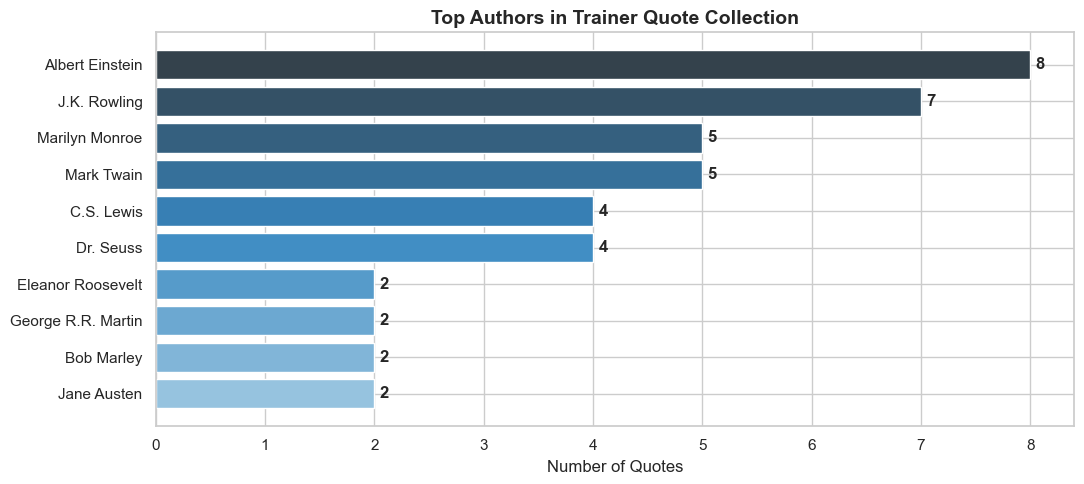

In [8]:
top_authors = df['author'].value_counts().head(10)

plt.figure(figsize=(11, 5))
bars = plt.barh(top_authors.index[::-1], top_authors.values[::-1],
                color=sns.color_palette('Blues_d', len(top_authors)))

for bar, val in zip(bars, top_authors.values[::-1]):
    plt.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontweight='bold')

plt.title('Top Authors in Trainer Quote Collection', fontsize=14, fontweight='bold')
plt.xlabel('Number of Quotes')
plt.tight_layout()
plt.savefig('trainer_top_authors.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
print("df shape:", df.shape)
print("df columns:", df.columns.tolist())
print()
print("df_all shape:", df_all.shape)
print("df_all columns:", df_all.columns.tolist())
print()
print("all_quotes length:", len(all_quotes))
if len(all_quotes) > 0:
    print("First entry:", all_quotes[0])

df shape: (40, 4)
df columns: ['quote', 'author', 'tags', 'word_count']

df_all shape: (40, 4)
df_all columns: ['quote', 'author', 'tags', 'word_count']

all_quotes length: 40
First entry: {'quote': 'The only way to do great work is to love what you do.', 'author': 'Steve Jobs', 'tags': 'passion, work, growth', 'word_count': 14}


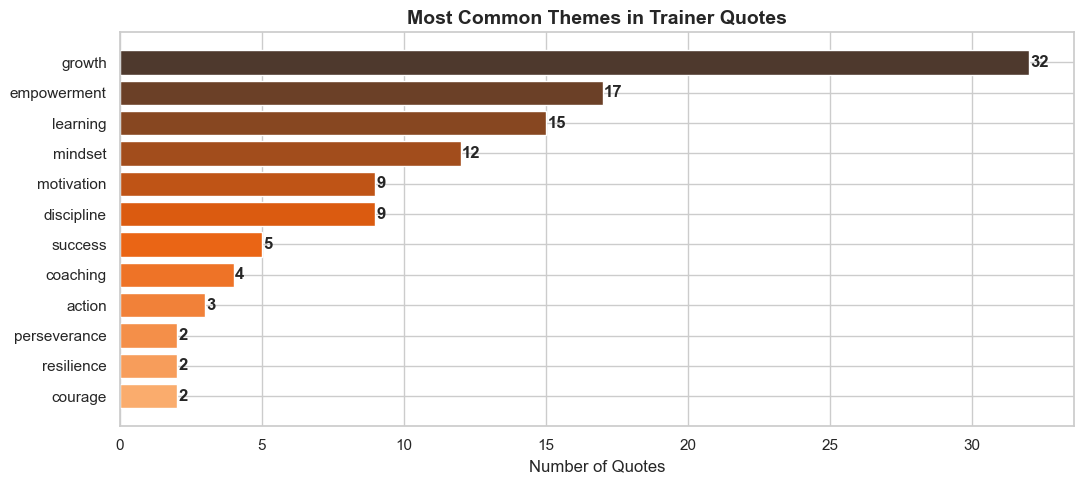

In [22]:
all_tags = df['tags'].dropna().str.split(', ').explode()
all_tags = all_tags[all_tags != '']
top_tags = all_tags.value_counts().head(12)

plt.figure(figsize=(11, 5))
bars = plt.barh(top_tags.index[::-1], top_tags.values[::-1],
                color=sns.color_palette('Oranges_d', len(top_tags)))

for bar, val in zip(bars, top_tags.values[::-1]):
    plt.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontweight='bold')

plt.title('Most Common Themes in Trainer Quotes', fontsize=14, fontweight='bold')
plt.xlabel('Number of Quotes')
plt.tight_layout()
plt.savefig('trainer_top_tags.png', dpi=150, bbox_inches='tight')
plt.show()

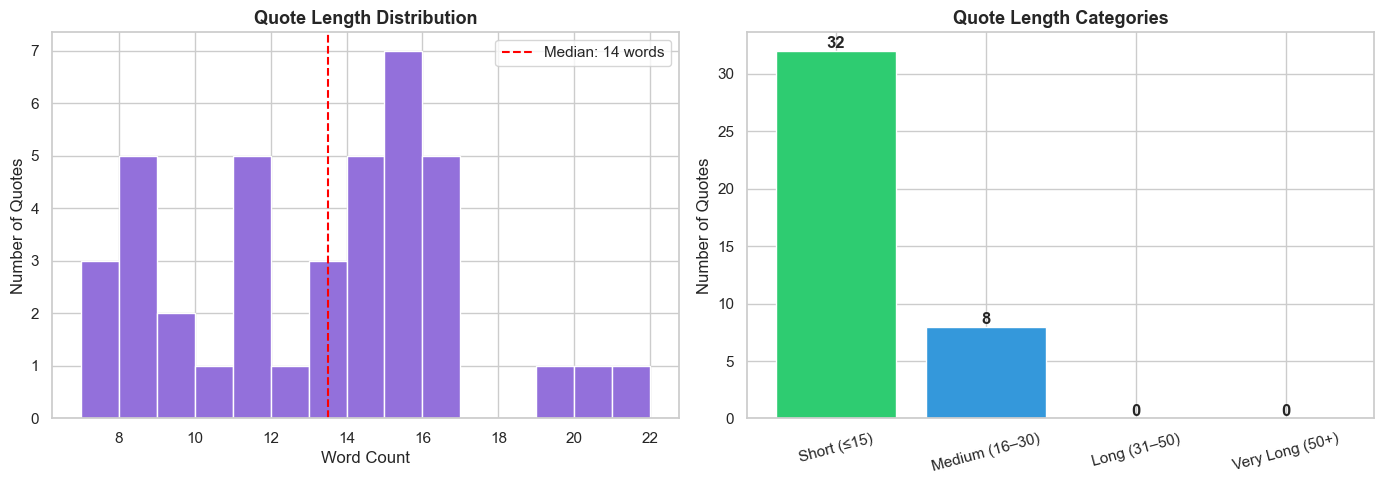

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['word_count'], bins=15, color='mediumpurple', edgecolor='white')
axes[0].axvline(df['word_count'].median(), color='red', linestyle='--',
                label=f'Median: {df["word_count"].median():.0f} words')
axes[0].set_title('Quote Length Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Number of Quotes')
axes[0].legend()

bins = pd.cut(df['word_count'], bins=[0, 15, 30, 50, 200],
              labels=['Short (≤15)', 'Medium (16–30)', 'Long (31–50)', 'Very Long (50+)'])
bin_counts = bins.value_counts().sort_index()

axes[1].bar(bin_counts.index, bin_counts.values,
            color=['#2ecc71', '#3498db', '#e67e22', '#e74c3c'], edgecolor='white')
axes[1].set_title('Quote Length Categories', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Quotes')
axes[1].tick_params(axis='x', rotation=15)

for i, v in enumerate(bin_counts.values):
    axes[1].text(i, v + 0.2, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('trainer_quote_lengths.png', dpi=150, bbox_inches='tight')
plt.show()

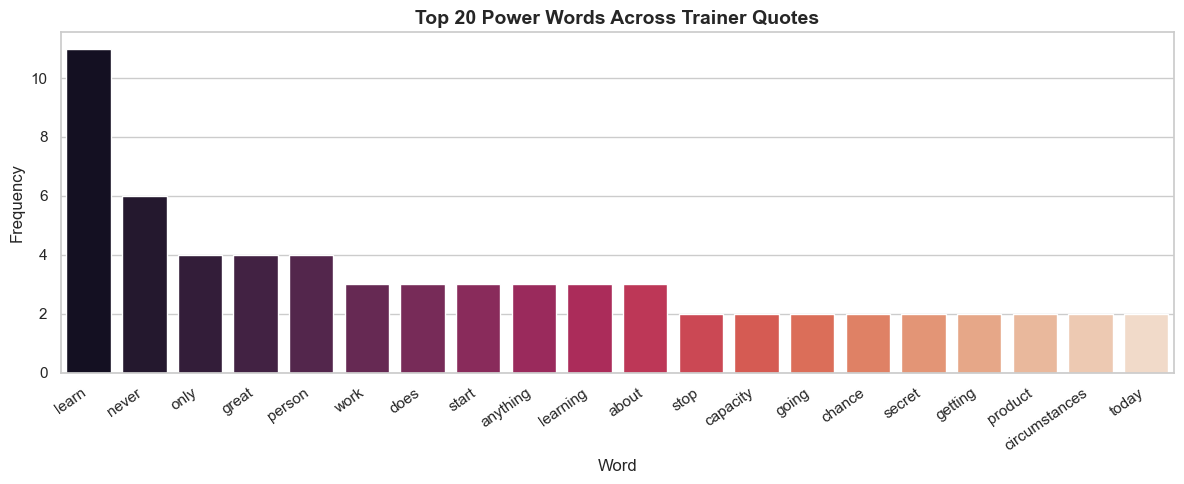

In [24]:
STOPWORDS = {
    'the','a','an','and','or','but','in','on','at','to','for','of','is',
    'it','i','you','that','this','with','not','be','are','was','have',
    'as','if','they','we','he','she','do','so','by','from','all','can',
    'my','your','our','has','had','will','what','when','there','who','no',
    'one','more','than','its','been','which','their','him','her','me','us'
}

all_words = ' '.join(df['quote']).lower()
words = re.findall(r'\b[a-z]{4,}\b', all_words)
filtered_words = [w for w in words if w not in STOPWORDS]

word_freq = Counter(filtered_words).most_common(20)
words_df = pd.DataFrame(word_freq, columns=['word', 'count'])

plt.figure(figsize=(12, 5))
sns.barplot(data=words_df, x='word', y='count', hue='word', palette='rocket', legend=False)
plt.title('Top 20 Power Words Across Trainer Quotes', fontsize=14, fontweight='bold')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig('trainer_power_words.png', dpi=150, bbox_inches='tight')
plt.show()




In [25]:
social_quotes = df[df['word_count'] <= 15].sort_values('word_count')

print(f'🎯 {len(social_quotes)} short quotes perfect for social media / sessions:\n')
for _, row in social_quotes.iterrows():
    print(f'"{row["quote"]}"')
    print(f'  — {row["author"]} ({row["word_count"]} words)\n')

🎯 32 short quotes perfect for social media / sessions:

"Great things never came from comfort zones."
  — Unknown (7 words)

"It always seems impossible until it's done."
  — Nelson Mandela (7 words)

"Believe you can and you're halfway there."
  — Theodore Roosevelt (7 words)

"An investment in knowledge pays the best interest."
  — Benjamin Franklin (8 words)

"The more I practice, the luckier I get."
  — Gary Player (8 words)

"The expert in anything was once a beginner."
  — Helen Hayes (8 words)

"The secret of getting ahead is getting started."
  — Mark Twain (8 words)

"What we learn with pleasure we never forget."
  — Alfred Mercier (8 words)

"Hard work beats talent when talent doesn't work hard."
  — Tim Notke (9 words)

"Small daily improvements over time lead to stunning results."
  — Robin Sharma (9 words)

"Don't watch the clock; do what it does. Keep going."
  — Sam Levenson (10 words)

"A person who never made a mistake never tried anything new."
  — Albert Einstein (11

In [26]:

social_quotes[['quote', 'author']].to_csv('trainer_quotes_social.csv', index=False)
print('✅ Saved short quotes to trainer_quotes_social.csv')

✅ Saved short quotes to trainer_quotes_social.csv


In [27]:
print('=== TRAINER QUOTES — SUMMARY ===')
print(f'Total quotes collected       : {len(df)}')
print(f'Unique authors               : {df["author"].nunique()}')
print(f'Most represented author      : {df["author"].value_counts().idxmax()}')
print(f'Top theme/tag                : {all_tags.value_counts().idxmax()}')
print(f'Average quote length         : {df["word_count"].mean():.1f} words')
print(f'Short quotes (social-ready)  : {len(social_quotes)}')
print(f'\nFiles saved:')
print('  trainer_quotes.csv         — full filtered collection')
print('  trainer_quotes_social.csv  — short quotes only (≤15 words)')

=== TRAINER QUOTES — SUMMARY ===
Total quotes collected       : 40
Unique authors               : 35
Most represented author      : Unknown
Top theme/tag                : growth
Average quote length         : 12.8 words
Short quotes (social-ready)  : 32

Files saved:
  trainer_quotes.csv         — full filtered collection
  trainer_quotes_social.csv  — short quotes only (≤15 words)
